In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## BASIC DATA CLEANING

In [3]:

df = pd.read_csv('train.csv')
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# missing values handling
print(df.isnull().sum())

# Age = 177, Cabin = 687, Embarked = 2
# Handle the age col
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Handle the Embarked column
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# deleted the Cabin column as it has maximum fields NaN 
df = df.drop("Cabin", axis = 1)
df



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [5]:

def class_func(cl):
    if cl == "1":
        return "First"
    elif cl == "2":
        return "Second"
    elif cl == "3":
        return "Third"
    
# make these columns categorical
df['Survived'] = df['Survived'].astype(str)
df['Pclass'] = df['Pclass'].astype(str).apply(class_func)

df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,Third,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,First,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,Third,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,First,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,Third,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,Second,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,First,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,Third,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,First,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [6]:

# Treat passenger ID as index rather than a feature
df = df.set_index('PassengerId')

# No duplicate rows are present here in the dataset




## Exploratory data analysis


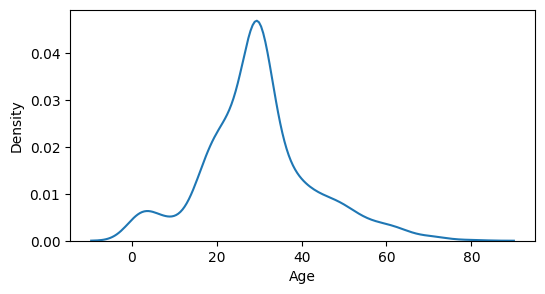

In [7]:

# statistical overview of features
df.describe()

# get the distribution of Age and Fare
age_dist = df['Age'].value_counts()
fare_dist = df['Fare'].value_counts()

plt.figure(figsize=(6, 3))
sns.kdeplot(df['Age'])
plt.show()


In [8]:

# count the passengers by sex, pclass and embarked

count_by_age = df.groupby('Sex')['Survived'].count()
count_by_age = df.groupby('Pclass')['Survived'].count()
count_by_age = df.groupby('Embarked')['Survived'].count()




In [9]:

# survival rate by gender
survival_female, survival_male = round(df.groupby('Sex')['Survived'].count() / len(df) * 100, 2)
f"Percentage of female Survival : {survival_female}% and male survival : {survival_male}%."

#Survival rate by Class
survival_fclass, survival_sclass, survival_thclass = round(df.groupby('Pclass')['Survived'].count() / len(df) * 100, 2)
f"Percentage of First class survival : {survival_fclass}%, Second class survival : {survival_sclass}% and Third class survival : {survival_thclass}%."

survived_mean, non_survived_mean = df.groupby('Survived')['Age'].mean()
f"Mean of survival age: {round(survived_mean, 2)} and Mean of non-survival age: {round(non_survived_mean, 2)}"


'Mean of survival age: 30.42 and Mean of non-survival age: 28.55'


## Feature engineering tasks


In [10]:

# Create a new Family size column
df['Family Size'] = df['SibSp'] + df['Parch']
df



,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size
PassengerId,,,,,,,,,,,
1,0,Third,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1
2,1,First,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,1
3,1,Third,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0
4,1,First,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1
5,0,Third,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...
887,0,Second,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,0
888,1,First,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0
889,0,Third,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3


In [11]:
# Remove the titles  from the name column
to_be_removed = ['Mr.', 'Miss.', 'Rev.']
def remove_title(name):
    for title in ['Mr.', 'Miss.', 'Rev.', "Mrs."]:
        name = name.replace(title, "")
    return name.strip()

df['Name'] = df['Name'].apply(remove_title)

df


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size
PassengerId,,,,,,,,,,,
1,0,Third,"Braund, Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1
2,1,First,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.2833,C,1
3,1,Third,"Heikkinen, Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0
4,1,First,"Futrelle, Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1
5,0,Third,"Allen, William Henry",male,35.000000,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...
887,0,Second,"Montvila, Juozas",male,27.000000,0,0,211536,13.0000,S,0
888,1,First,"Graham, Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0
889,0,Third,"Johnston, Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3


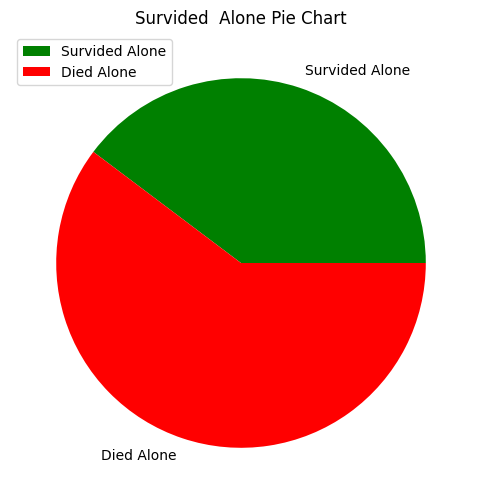

In [12]:

# make a new feature that stores the isAlone for faamiity sizes having zero 
df['Is Alone'] = df['Family Size'].apply(lambda x: x == 0)

# now check the survival rate of the alone people
survived_alone, not_survived_alone = np.round(df.groupby('Is Alone')['Survived'].count() / len(df['Survived']) * 100 , 2)
plt.figure(figsize=(12,6))
plt.pie([survived_alone, not_survived_alone], labels = ["Survided Alone", "Died Alone"], colors=["green", "red"])
plt.title("Survided  Alone Pie Chart")
plt.legend()
plt.show()


C:\Users\Arpan\AppData\Local\Temp\ipykernel_9936\1604677060.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(sex_wise_survival, palette="muted")


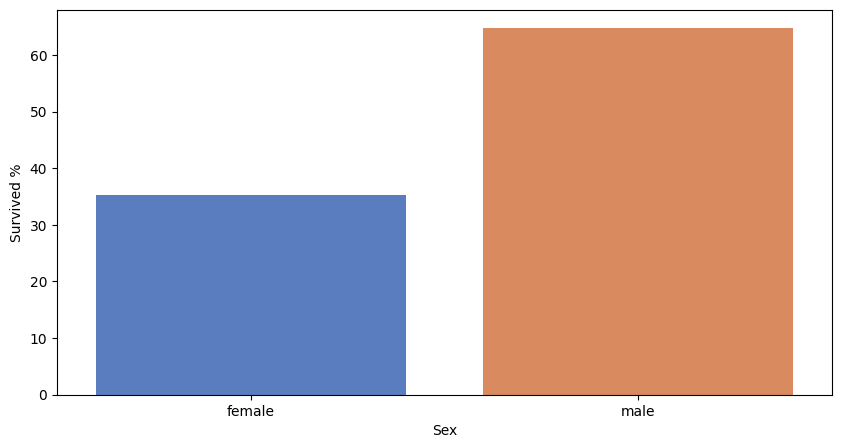

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size,Is Alone
PassengerId,,,,,,,,,,,,
1,0,Third,"Braund, Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,False
2,1,First,"Cumings, John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C,1,False
3,1,Third,"Heikkinen, Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,True
4,1,First,"Futrelle, Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,False
5,0,Third,"Allen, William Henry",male,35,0,0,373450,8.0500,S,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,Second,"Montvila, Juozas",male,27,0,0,211536,13.0000,S,0,True
888,1,First,"Graham, Margaret Edith",female,19,0,0,112053,30.0000,S,0,True
889,0,Third,"Johnston, Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S,3,False


In [13]:
# Gender wise survival calculation
sex_wise_survival = np.round(df.groupby("Sex")['Survived'].count() / len(df['Survived']) * 100, 2)
plt.figure(figsize=(10,5))
sns.barplot(sex_wise_survival, palette="muted")
plt.ylabel("Survived %")
plt.show()

df['Age'] = (df['Age']).astype(int)
df


## Scikit-Learn to Predict Survival


In [14]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
df.columns
# Label encode the columns having categorical data
le = LabelEncoder()
for i in ['Pclass', 'Sex', 'Embarked']:
    df[i] = le.fit_transform(df[i])

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked', 'Family Size', 'Is Alone']]
Y = df['Survived']
# Min Max Scaling
mm = MinMaxScaler()
transformed_df = X.copy().select_dtypes(include = "number").astype(float)
transformed_df.iloc[:, :] = mm.fit_transform(transformed_df.iloc[:, :])
transformed_df.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family Size
PassengerId,,,,,,,,
1,1.0,1.0,0.2750,0.125,0.0,0.014151,1.0,0.1
2,0.0,0.0,0.4750,0.125,0.0,0.139136,0.0,0.1
3,1.0,0.0,0.3250,0.000,0.0,0.015469,1.0,0.0
4,0.0,0.0,0.4375,0.125,0.0,0.103644,1.0,0.1
5,1.0,1.0,0.4375,0.000,0.0,0.015713,1.0,0.0


In [15]:
# now use the Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

# Perform Linear Regression on the dataset
lin = LinearRegression()
lin.fit(X_train, Y_train)

y_pred = lin.predict(X_test)
y_pred_binary = np.where(y_pred > 0.5, '1', '0')

accuracy = accuracy_score(Y_test, y_pred_binary)
f"The model is {accuracy * 100:.2f}% accurate in Linear Regression"


'The model is 84.75% accurate in Linear Regression'

In [ ]:
# now use the logistic regression

from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
log.fit(X_train, Y_train)

y_pred_log = log.predict(X_test)

y_prob = log.predict_proba(X_test)[:,1]

accuracy_log = accuracy_score(Y_test, y_pred_log)
f"The model is {accuracy_log * 100:.2f}% accurate in Logistic Regression"

'The model is 84.75% accurate in Logistic Regression'